In [1]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command

In [2]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [3]:
from agent.states import GlobalState
from agent.orchestration.elicitation import elicitation_stage
from agent.orchestration.planning import planning_stage
from agent.orchestration.design import design_stage
from agent.orchestration.validation import validation_stage
from agent.orchestration.output import output_stage

In [4]:
main_graph = StateGraph(GlobalState)

main_graph.add_node("Elicitation", elicitation_stage)
main_graph.add_node("Planning", planning_stage)
main_graph.add_node("Design", design_stage)
main_graph.add_node("Validation", validation_stage)
main_graph.add_node("Output", output_stage)

main_graph.set_entry_point("Elicitation")
main_graph.add_edge("Elicitation", "Planning")
main_graph.add_edge("Planning", "Design")
main_graph.add_edge("Design", "Validation")
main_graph.add_edge("Validation", "Output")
main_graph.add_edge("Output", END)

agent = main_graph.compile(checkpointer=MemorySaver())

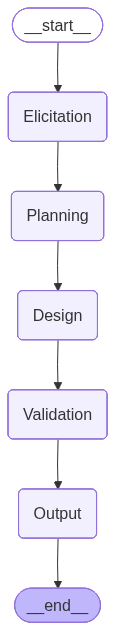

In [5]:
agent

In [6]:
import json

output = {}
filename = "results/test_case_4.json"

In [ ]:
async def run_stream(stream):
	try:
		async for step_output in stream:
			stage_name, stage_output = step_output
			node_name = next(iter(stage_output), None)
			print(f"Stage name: {stage_name}", "Node name:", node_name)
			
			if node_name == "__interrupt__":
				print("Interrupt received:", stage_output["__interrupt__"][0].value)
				break

			elif node_name and stage_output[node_name]:
				output.update(stage_output[node_name])
	
	finally:
		print(f"Saving output to {filename}...")

		with open(filename, "w") as f:
			json.dump(output, f, indent=4)

In [8]:
stream = agent.astream({
  "user_input": "Build a platform like Uber but for home services"
}, {"configurable": {"thread_id": "user-1"}
}, stream_mode="updates", subgraphs=True)

await run_stream(stream)

Stage name: ('Elicitation:664c609b-602d-9777-ddeb-633e9e8c60d3',) Node name: requirement_specs
Stage name: ('Elicitation:664c609b-602d-9777-ddeb-633e9e8c60d3',) Node name: __interrupt__
Interrupt received: {'type': 'clarification', 'details': [{'field': 'geographic_coverage', 'input_type': 'string'}, {'field': 'service_categories', 'input_type': 'list'}, {'field': 'regulatory_requirements', 'input_type': 'list'}, {'field': 'scale_hint', 'input_type': 'string'}, {'field': 'consistency', 'input_type': 'string'}, {'field': 'timeline', 'input_type': 'string'}, {'field': 'budget', 'input_type': 'string'}, {'field': 'team_size', 'input_type': 'string'}, {'field': 'security', 'input_type': 'string'}]}
Stage name: () Node name: __interrupt__
Interrupt received: {'type': 'clarification', 'details': [{'field': 'geographic_coverage', 'input_type': 'string'}, {'field': 'service_categories', 'input_type': 'list'}, {'field': 'regulatory_requirements', 'input_type': 'list'}, {'field': 'scale_hint', '

In [10]:
stream = agent.astream(
	Command(resume={
		"Specific home services categories": ["Plumbing", "Electrical", "Cleaning"],
		"Geographic rollout strategy": "Start in major metropolitan areas in india",
		"budget": "$500 for first 6 months",
		"development timeline": "3 months for MVP, 6 months for full launch",
	}),
	{"configurable": {"thread_id": "user-1"}},
	stream_mode="updates", subgraphs=True
)

await run_stream(stream)

Stage name: ('Elicitation:651efec3-f18e-a039-dd29-6de36c65657b',) Node name: clarify
Stage name: ('Elicitation:651efec3-f18e-a039-dd29-6de36c65657b',) Node name: requirement_specs
Stage name: () Node name: Elicitation
Stage name: ('Planning:769de1f8-da2b-7c1a-6461-077cda4a50f3',) Node name: Architecture Planning
Stage name: ('Planning:769de1f8-da2b-7c1a-6461-077cda4a50f3',) Node name: __interrupt__
Interrupt received: (Interrupt(value={'type': 'checkpoint', 'approval': {'message': 'Do you approve this architecture?', 'type': 'boolean'}, 'changes_requested': {'message': 'If not approved, please suggest changes or pick an alternative.', 'type': 'text', 'options': ['monolith', 'modular_monolith', 'microservices']}}, id='4eaee5f450522fb7556ef93c3e114c83'),)
Saving output to results/test_case_1.json...


In [11]:
stream = agent.astream(
	Command(resume={
		"approval": True,
		"changes_requested": "",
	}),
	{"configurable": {"thread_id": "user-1"}},
	stream_mode="updates", subgraphs=True
)

await run_stream(stream)

Stage name: ('Planning:769de1f8-da2b-7c1a-6461-077cda4a50f3',) Node name: User Checkpoint
Stage name: ('Planning:769de1f8-da2b-7c1a-6461-077cda4a50f3',) Node name: Tech Stack Selection
Stage name: () Node name: Planning
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: services_design
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: api_design
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: infrastructure_planning
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: database_design
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: api_parallel_design
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: db_parallel_design
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: infra_parallel_design
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: __interrupt__
Interrupt received: (Interrupt(value={'type': 'checkpoint', 'a

In [12]:
stream = agent.astream(
	Command(resume={
		"approval": True,
		"changes_requested": "",
	}),
	{"configurable": {"thread_id": "user-1"}},
	stream_mode="updates", subgraphs=True,
)

await run_stream(stream)

Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: user_checkpoint
Stage name: ('Design:af17b2a6-178f-e872-2dda-c93f9eb9f831',) Node name: design_aggregation
Stage name: () Node name: Design
Stage name: ('Validation:d1c2910b-5a77-70e3-1009-e6d0e3637a93',) Node name: requirements_alignment
Stage name: ('Validation:d1c2910b-5a77-70e3-1009-e6d0e3637a93',) Node name: cross_component_validation
Stage name: ('Validation:d1c2910b-5a77-70e3-1009-e6d0e3637a93',) Node name: decision_optimization
Stage name: ('Validation:d1c2910b-5a77-70e3-1009-e6d0e3637a93',) Node name: scoring
Stage name: () Node name: Validation
Stage name: ('Output:93de1c9f-4d49-1cf5-71ff-3754c1d51558',) Node name: output_assembly
Stage name: () Node name: Output
Saving output to results/test_case_1.json...
